<a href="https://colab.research.google.com/github/enzosakamoto/ecm514-projeto-I/blob/main/src/IMT_Projeto_S1_enzo_joao_pedro_rafael_vitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis (EDA)**
##Análise sobre saneamento básico e sua relação com os resultados do ENEM 2020

In [3]:
#@title **Identificação do Grupo**

Aluno1 = 'Enzo Yuji Sakamoto, 21.00210-0' #@param {type:"string"}
Aluno2 = 'João Vitor Choueri Branco, 21.01075-7' #@param {type:"string"}
Aluno3 = 'Pedro Henrique de Sousa Matumoto, 21.00784-5' #@param {type:"string"}
Aluno4 = 'Rafael Rubio Carnes, 20.00611-0' #@param {type:"string"}
Aluno5 = 'Vitor Guirão Soller, 21.01444-2' #@param {type:"string"}





# Importação de bibliotecas


# **Resumo (*Abstract*)** 🏗️🏗️

`O seguinte projeto estuda os dados fornecido pelo Sistema Nacional de Informações sobre Saneamento (SNIS) e a suas relações com o resultado do ENEM 2020. Primeiramente foi necessário cruzar a base, constatando que cerca de XX% dos dados não poderiam ser utilizados por não contarem com o munícipio. Após isto, foram realizados diversos cortes



# **Introdução** 🏗️

Faça uma breve introdução do seu trabalho. Conceitue os pontos relevantes do seu  problema e, se for o caso, das técnicas de análise empregadas. Discuta a relevância, atualidade, limitações das análises existentes e o impacto que  sua análise pode trazer.

# **Descrição e origem dos dados**

## Os dados foram retirados de fontes oficiais do governo

### Sistema Nacional de Informações sobre Saneamento (SNIS)
https://basedosdados.org/dataset/2a543ad8-3cdb-4047-9498-efe7fb8ed697?table=df7cf198-4889-4baf-bb77-4e0e28eb90ca

O SNIS é uma unidade vinculada à Secretaria Nacional de Saneamento (SNS) do Ministério do Desenvolvimento Regional (MDR). Essa tabela contém informações e indicadores consolidados por município referentes aos serviços de água e esgoto, proporcionando um panorama detalhado do histórico e do estado do saneamento básico no Brasil. Os dados são provenientes da Série Histórica de Municípios e abrangem o período de 1995 a 2022.

Para o seguinte projeto, foram recortados os dados do ano de 2020.

### ENEM
https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem
Os microdados são provenientes do Exame Nacional do Ensino Médio (Enem), uma iniciativa do Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira (Inep), que é vinculada ao Ministério da Educação (MEC).

Esses microdados representam o menor nível de desagregação de dados recolhidos por meio do exame. Eles incluem informações detalhadas como as provas aplicadas, os gabaritos, dados sobre os itens das questões, as notas dos participantes e o questionário socioeconômico respondido pelos inscritos no Enem. Os microdados do Enem estão disponíveis para consulta e uso desde o ano de 1998 até 2023.

Para o seguinte projeto, foram recortados os dados do ano de 2020.

### Cruzamento dentre os dados do ENEM e do SNIS
Para cruzamento foi com base no município o estados, portanto as análises foram feitas sobre isso.


### Localização dos dados

Como ambas as bases precisam ser baixadas de formas manual, salvamos no diretório `/work` em nosso repositório para garantir que o *notebook* seja totalmente executável







In [ ]:
import pandas as pd
import numpy as np
from pprint import pprint
from pandas import ExcelFile
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# **Aquisição e Preparação dos dados**

Faça aqui a aquisição dos dados, justificando e incluindo aqui eventuais reduções as efetuadas.

Não deixe de descrever e justificar reduções (seleções) feitas nos dados originais para os seus propósitos (por exemplo, selecionou somente dados do último ano, somente dados de países da América Latina ou selecionou somente algumas tabelas dentre várias tabelas disponíveis).








## Mapeamento da tradução dos microdados


In [ ]:
micro_dados = ExcelFile("../datasets/Dicionario_Microdados_Enem_2023.xlsx").sheet_names[
    1:-1
]

pprint(micro_dados)

['TP_SIT_FUNC_ESC',
 'TP_DEPENDENCIA_ADM_ESC',
 'TP_LOCALIZACAO_ESC',
 'TP_FAIXA_ETARIA',
 'TP_SEXO',
 'TP_ESTADO_CIVIL',
 'TP_COR_RACA',
 'TP_NACIONALIDADE',
 'TP_ST_CONCLUSAO',
 'TP_ANO_CONCLUIU',
 'TP_ESCOLA',
 'TP_ENSINO',
 'IN_TREINEIRO',
 'TP_PRESENCA_CN',
 'TP_PRESENCA_CH',
 'TP_PRESENCA_LC',
 'TP_PRESENCA_MT',
 'TP_LINGUA',
 'TP_STATUS_REDACAO',
 'Q001',
 'Q002',
 'Q003',
 'Q004',
 'Q005',
 'Q006',
 'Q007',
 'Q008',
 'Q009',
 'Q010',
 'Q011',
 'Q012',
 'Q013',
 'Q014',
 'Q015',
 'Q016',
 'Q017',
 'Q018',
 'Q019',
 'Q020',
 'Q021',
 'Q022',
 'Q023',
 'Q024',
 'Q025']


## Leitura traduções


In [ ]:
df_micro_dados = {
    planilha: pd.read_excel(
        f"../datasets/Dicionario_Microdados_Enem_2023.xlsx",
        sheet_name=planilha,
        header=0,
    )
    for planilha in micro_dados
}

pprint(list(df_micro_dados.keys()))

['TP_SIT_FUNC_ESC',
 'TP_DEPENDENCIA_ADM_ESC',
 'TP_LOCALIZACAO_ESC',
 'TP_FAIXA_ETARIA',
 'TP_SEXO',
 'TP_ESTADO_CIVIL',
 'TP_COR_RACA',
 'TP_NACIONALIDADE',
 'TP_ST_CONCLUSAO',
 'TP_ANO_CONCLUIU',
 'TP_ESCOLA',
 'TP_ENSINO',
 'IN_TREINEIRO',
 'TP_PRESENCA_CN',
 'TP_PRESENCA_CH',
 'TP_PRESENCA_LC',
 'TP_PRESENCA_MT',
 'TP_LINGUA',
 'TP_STATUS_REDACAO',
 'Q001',
 'Q002',
 'Q003',
 'Q004',
 'Q005',
 'Q006',
 'Q007',
 'Q008',
 'Q009',
 'Q010',
 'Q011',
 'Q012',
 'Q013',
 'Q014',
 'Q015',
 'Q016',
 'Q017',
 'Q018',
 'Q019',
 'Q020',
 'Q021',
 'Q022',
 'Q023',
 'Q024',
 'Q025']


## Leitura dos microdados


In [ ]:
MAXIMO = 1_000_000 # Utilizado para debug e testes mais rápidos

df = pd.read_csv(
    "../datasets/MICRODADOS_ENEM_2020.csv", sep=";", encoding="ISO-8859-1"
)

df.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,200006271946,2020,11,F,1,2,1,1,11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200001195856,2020,11,M,2,3,1,1,11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,200001943954,2020,4,F,2,3,2,2,0,2,...,B,A,A,B,A,A,A,A,A,A
3,200001908998,2020,2,M,1,3,1,2,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,200001634757,2020,4,F,1,3,2,1,1,1,...,A,A,A,B,A,B,B,A,A,B


### Drop de colunas desnecessárias


In [ ]:
df.drop(
    columns=[
        # Dados da prova objetiva
        "CO_PROVA_CN",
        "CO_PROVA_CH",
        "CO_PROVA_LC",
        "CO_PROVA_MT",
        "TX_RESPOSTAS_CN",
        "TX_RESPOSTAS_CH",
        "TX_RESPOSTAS_LC",
        "TX_RESPOSTAS_MT",
        "TX_GABARITO_CN",
        "TX_GABARITO_CH",
        "TX_GABARITO_LC",
        "TX_GABARITO_MT",
        # Dados da redação
        "NU_NOTA_COMP1",
        "NU_NOTA_COMP2",
        "NU_NOTA_COMP3",
        "NU_NOTA_COMP4",
        "NU_NOTA_COMP5",
    ],
    inplace=True,
)

## Cruzamento das traduções com os microdados


In [ ]:
# for coluna in ["CO_MUNICIPIO_ESC", "CO_MUNICIPIO_PROVA", "CO_UF_ESC", "CO_UF_PROVA"]:
#     df[coluna] = df[coluna].replace(np.nan, 0).astype(int)

# for coluna in [
#     "NU_NOTA_CN",
#     "NU_NOTA_CH",
#     "NU_NOTA_LC",
#     "NU_NOTA_MT",
#     "NU_NOTA_REDACAO",
# ]:
#     df[coluna] = df[coluna].replace(np.nan, 0).astype(float)

# Dropar linhas com CO_MUNICIPIO_ESC nulo
df = df.dropna(subset=["CO_MUNICIPIO_ESC", "CO_MUNICIPIO_PROVA", "CO_UF_ESC", "CO_UF_PROVA"])

# for tabela in df_micro_dados:
#     df = df.merge(df_micro_dados[tabela], on=tabela)

# df = df.drop(columns=df_micro_dados.keys())

df.shape

(904569, 59)

In [ ]:
df_saneamento = pd.read_csv("../datasets/br_mdr_snis_municipio_agua_esgoto.csv")

df_saneamento = df_saneamento[df_saneamento.ano == 2020].reset_index(drop=True)

df_saneamento.columns = df_saneamento.columns.str.upper()

df_saneamento.head()

,ANO,ID_MUNICIPIO,SIGLA_UF,POPULACAO_ATENDIDA_AGUA,POPULACAO_ATENTIDA_ESGOTO,POPULACAO_URBANA,POPULACAO_URBANA_RESIDENTE_AGUA,POPULACAO_URBANA_ATENDIDA_AGUA,POPULACAO_URBANA_ATENDIDA_AGUA_IBGE,POPULACAO_URBANA_RESIDENTE_ESGOTO,...,INVESTIMENTO_RECURSO_ONEROSO_MUNICIPIO,INVESTIMENTO_RECURSO_NAO_ONEROSO_MUNICIPIO,INVESTIMENTO_TOTAL_MUNICIPIO,INVESTIMENTO_AGUA_ESTADO,INVESTIMENTO_ESGOTO_ESTADO,INVESTIMENTO_OUTRO_ESTADO,INVESTIMENTO_RECURSO_PROPRIO_ESTADO,INVESTIMENTO_RECURSO_ONEROSO_ESTADO,INVESTIMENTO_RECURSO_NAO_ONEROSO_ESTADO,INVESTIMENTO_TOTAL_ESTADO
0,2020,2905107,BA,6942.0,547.0,3193.0,3193.0,3193.0,9058.0,3193.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020,2909505,BA,3632.0,2763.0,3376.0,3376.0,3336.0,5351.0,3376.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020,2910750,BA,16076.0,8000.0,6992.0,6992.0,6975.0,17845.0,6992.0,...,NaN,NaN,228725.81,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020,2915106,BA,9516.0,12242.0,9577.0,9577.0,9516.0,12242.0,9577.0,...,NaN,NaN,74000.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020,2917607,BA,41625.0,15885.0,41639.0,41639.0,41625.0,54673.0,41639.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Munícipios que tiveram prova do ENEM mas que não estão na pesquisa


In [ ]:
df.CO_MUNICIPIO_PROVA.nunique()

1747

In [ ]:
df_saneamento.ID_MUNICIPIO.nunique()

5338

In [ ]:
df.CO_MUNICIPIO_PROVA.nunique() - df_saneamento.ID_MUNICIPIO.nunique()

-3591

In [ ]:
df[~df.CO_MUNICIPIO_PROVA.isin(df_saneamento.ID_MUNICIPIO)]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
2205,200002145149,2020,2,F,1,3,1,2,0,2,...,A,A,A,B,A,A,C,A,B,A
3210,200001431391,2020,2,M,1,2,1,2,0,2,...,A,A,A,B,A,A,D,A,A,B
4288,200003055872,2020,2,M,1,2,1,2,0,2,...,A,A,A,B,A,A,C,A,B,B
5077,200001534216,2020,5,M,1,2,1,2,0,2,...,A,A,A,B,A,A,D,A,B,B
5273,200003016508,2020,2,F,1,3,1,2,0,2,...,B,A,A,B,A,B,B,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5778359,200002999270,2020,4,M,1,3,1,2,0,2,...,A,A,A,B,B,A,B,A,A,B
5779783,200006488798,2020,3,M,1,5,1,2,0,2,...,A,A,A,A,A,A,A,A,A,A
5782185,200001102302,2020,9,M,1,2,1,2,0,2,...,B,A,A,B,A,A,C,A,A,B
5782587,200003945158,2020,10,M,1,3,1,2,0,2,...,A,A,A,B,A,A,B,A,A,A


In [ ]:
df[~df.CO_MUNICIPIO_PROVA.isin(df_saneamento.ID_MUNICIPIO)].shape[0] / df.shape[0] * 100

0.7858991409168344

# **Análises** 🏗️

Busque orientar sua análise a perguntas que sejam feitas aos dados. Empregue de 5 a 6 perguntas relevantes, que podem estar relacionadas 1-2 temas dentro do problema escolhido. Empregue seleções, gráficos e outros recursos que julgar necessário para **comunicar** suas análises. Empregue instrumentos que dão suporte à sua análise, como correlações, gráficos, pareto, teste de hipóteses etc.

Abaixo um modelo opcional para as perguntas.

# Q1. A cobertura de abastecimento de água (indice_atendimento_total_agua) explica diferenças na nota média de redação?


In [ ]:
df_calculo_morador = df.copy()

df_calculo_morador = df_calculo_morador[df_calculo_morador["CO_MUNICIPIO_ESC"] != 0]
df_calculo_morador = df_calculo_morador[df_calculo_morador["IN_TREINEIRO"] == 0]
df_calculo_morador = df_calculo_morador[df_calculo_morador["TP_STATUS_REDACAO"] == 1]
df_calculo_morador = df_calculo_morador[df_calculo_morador["TP_PRESENCA_CN"] == 1]
df_calculo_morador = df_calculo_morador[df_calculo_morador["TP_PRESENCA_CH"] == 1]
df_calculo_morador = df_calculo_morador[df_calculo_morador["TP_PRESENCA_LC"] == 1]
df_calculo_morador = df_calculo_morador[df_calculo_morador["TP_PRESENCA_MT"] == 1]

nota_cols = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

df_calculo_morador.dropna(subset=nota_cols, inplace=True)

df_calculo_morador["NU_NOTA_TOTAL_INDIVIDUAL"] = df_calculo_morador[nota_cols].sum(
    axis=1
)

df_agregado_municipio = (
    df_calculo_morador.groupby(["CO_MUNICIPIO_ESC", "NO_MUNICIPIO_ESC"])
    .agg(
        SOMA_NOTAS_TOTAIS_MUNICIPIO=("NU_NOTA_TOTAL_INDIVIDUAL", "sum"),
        POPULACAO_CALCULO=("NU_INSCRICAO", "nunique")
    )
    .reset_index()
)

df_final_morador = df_agregado_municipio[df_agregado_municipio["POPULACAO_CALCULO"] > 0].copy()

df_final_morador["SOMA_NOTAS_POR_MORADOR"] = (
    df_final_morador["SOMA_NOTAS_TOTAIS_MUNICIPIO"]
    / df_final_morador["POPULACAO_CALCULO"]
)


df_final_morador["SOMA_NOTAS_POR_MORADOR"] = (
    df_final_morador["SOMA_NOTAS_POR_MORADOR"] / 4
)

df_final_morador = df_final_morador.merge(
    df_saneamento,
    left_on="CO_MUNICIPIO_ESC",
    right_on="ID_MUNICIPIO",
    how="inner",
)

df_final_morador


,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,SOMA_NOTAS_TOTAIS_MUNICIPIO,POPULACAO_CALCULO,SOMA_NOTAS_POR_MORADOR,ANO,ID_MUNICIPIO,SIGLA_UF,POPULACAO_ATENDIDA_AGUA,POPULACAO_ATENTIDA_ESGOTO,...,INVESTIMENTO_RECURSO_ONEROSO_MUNICIPIO,INVESTIMENTO_RECURSO_NAO_ONEROSO_MUNICIPIO,INVESTIMENTO_TOTAL_MUNICIPIO,INVESTIMENTO_AGUA_ESTADO,INVESTIMENTO_ESGOTO_ESTADO,INVESTIMENTO_OUTRO_ESTADO,INVESTIMENTO_RECURSO_PROPRIO_ESTADO,INVESTIMENTO_RECURSO_ONEROSO_ESTADO,INVESTIMENTO_RECURSO_NAO_ONEROSO_ESTADO,INVESTIMENTO_TOTAL_ESTADO
0,1100015.0,Alta Floresta D'Oeste,164790.1,62,664.476210,2020,1100015,RO,10716.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1100023.0,Ariquemes,668320.0,255,655.215686,2020,1100023,RO,92761.0,2280.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1100031.0,Cabixi,7383.3,3,615.275000,2020,1100031,RO,2332.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1100049.0,Cacoal,791163.6,290,682.037586,2020,1100049,RO,67689.0,46252.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1100056.0,Cerejeiras,87485.6,35,624.897143,2020,1100056,RO,10284.0,13821.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5184,5221908.0,Varjão,14729.6,6,613.733333,2020,5221908,GO,2394.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5185,5222005.0,Vianópolis,75402.7,29,650.023276,2020,5222005,GO,10262.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5186,5222203.0,Vila Boa,15242.8,7,544.385714,2020,5222203,GO,4532.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5187,5222302.0,Vila Propício,31511.8,13,605.996154,2020,5222302,GO,1719.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def plot_scatter(df: pd.DataFrame, x: str, y: str, ylabel: str) -> None:
    cols = [x, y]
    df_plot = df[cols].apply(pd.to_numeric, errors="coerce").dropna()

    X = df_plot[x]
    Y = df_plot[y]

    slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
    line_x = np.linspace(X.min(), X.max(), 200)
    line_y = intercept + slope * line_x

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(X, Y, alpha=0.6, edgecolor="k", label="Municipios")
    ax.plot(
        line_x,
        line_y,
        color="red",
        linewidth=2,
        label=f"y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r_value**2:.3f}",
    )

    ax.set_xlabel("Índice de atendimento total de água (%)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Cobertura de água vs. {ylabel}", fontsize=14, pad=12)
    ax.legend(frameon=False)
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

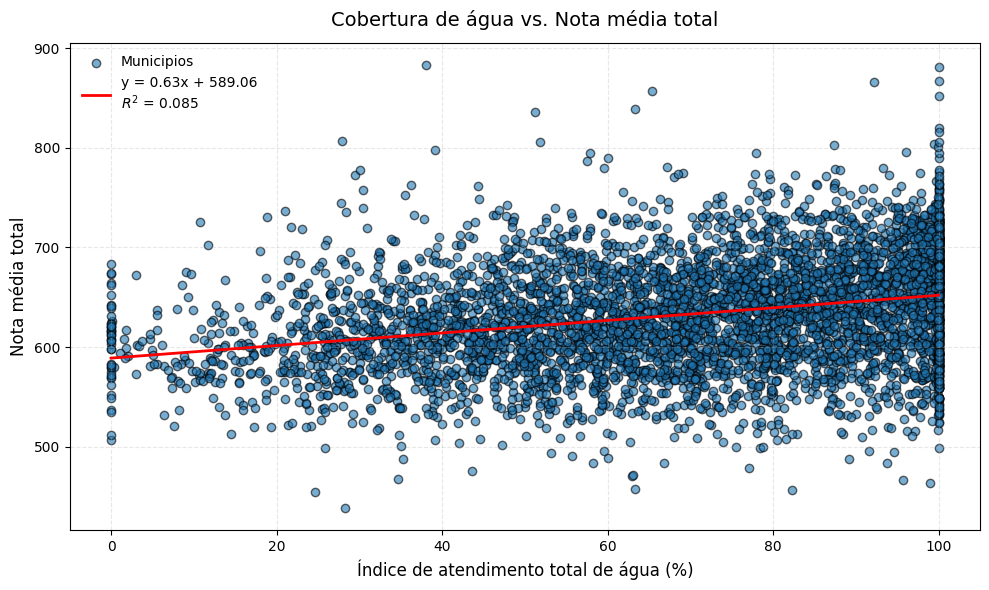

In [ ]:
coluna_notas = {
    "SOMA_NOTAS_POR_MORADOR": "Nota média total",
}

for nota in coluna_notas:
    plot_scatter(
        df_final_morador,
        x="INDICE_ATENDIMENTO_TOTAL_AGUA",
        y=nota,
        ylabel=coluna_notas[nota],
    )

### Análise
Analisando o resultado obtido, a diferença entre os alunos de maior desempenho e menor desempenho é de 60 pontos, condizente com algumas pesquisas feitas pelo grupo como [neste link](https://tratabrasil.org.br/enem-ausencia-de-saneamento-influencia-na-nota-media-dos-estudantes-que-realizam-a-prova/) e [neste link](https://www.poder360.com.br/opiniao/enem-e-saneamento-ausencia-do-basico-prejudica-estudantes/).

# Q2. Municípios com altas perdas na distribuição de água têm menor taxa de comparecimento ao exame?


In [ ]:
df_q2 = df.copy()
df_q2 = df_q2[df_q2.CO_MUNICIPIO_ESC != 0]
df_q2 = df_q2[df_q2.IN_TREINEIRO == 0]

df_q2["NAO_COMPARECEU_PELO_MENOS_1_DIA"] = (
    (df_q2.TP_PRESENCA_LC == 0)
    | (df_q2.TP_PRESENCA_CH == 0)
    | (df_q2.TP_PRESENCA_CN == 0)
    | (df_q2.TP_PRESENCA_MT == 0)
)

df_q2_group = (
    df_q2[df_q2.NAO_COMPARECEU_PELO_MENOS_1_DIA]
    .groupby(["CO_MUNICIPIO_ESC", "NO_MUNICIPIO_ESC"])
    .agg(
        NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT=(
            "NAO_COMPARECEU_PELO_MENOS_1_DIA",
            "sum",
        ),
        TOTAL=("NU_INSCRICAO", "count"),
    )
    .reset_index()
)

df_q2_group["TAXA_FALTA"] = (
    df_q2_group["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"] / df_q2_group["TOTAL"]
) * 100

df_q2_merged = df_q2_group.merge(
    df_saneamento, left_on="CO_MUNICIPIO_ESC", right_on="ID_MUNICIPIO"
).drop(columns=["ANO", "ID_MUNICIPIO"])[
    df_q2_group.columns.to_list() + ["INDICE_PERDA_DISTRIBUICAO_AGUA"]
]

df_q2_merged = df_q2_merged[df_q2_merged.INDICE_PERDA_DISTRIBUICAO_AGUA >= 80]

df_q2_merged.head()

,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT,TOTAL,TAXA_FALTA,INDICE_PERDA_DISTRIBUICAO_AGUA
16,1100205.0,Porto Velho,1434,1434,100.0,84.01
69,1200609.0,Tarauacá,61,61,100.0,80.87
72,1300029.0,Alvarães,140,140,100.0,83.16
121,1400233.0,Caroebe,15,15,100.0,82.03
125,1400456.0,Pacaraima,13,13,100.0,82.73


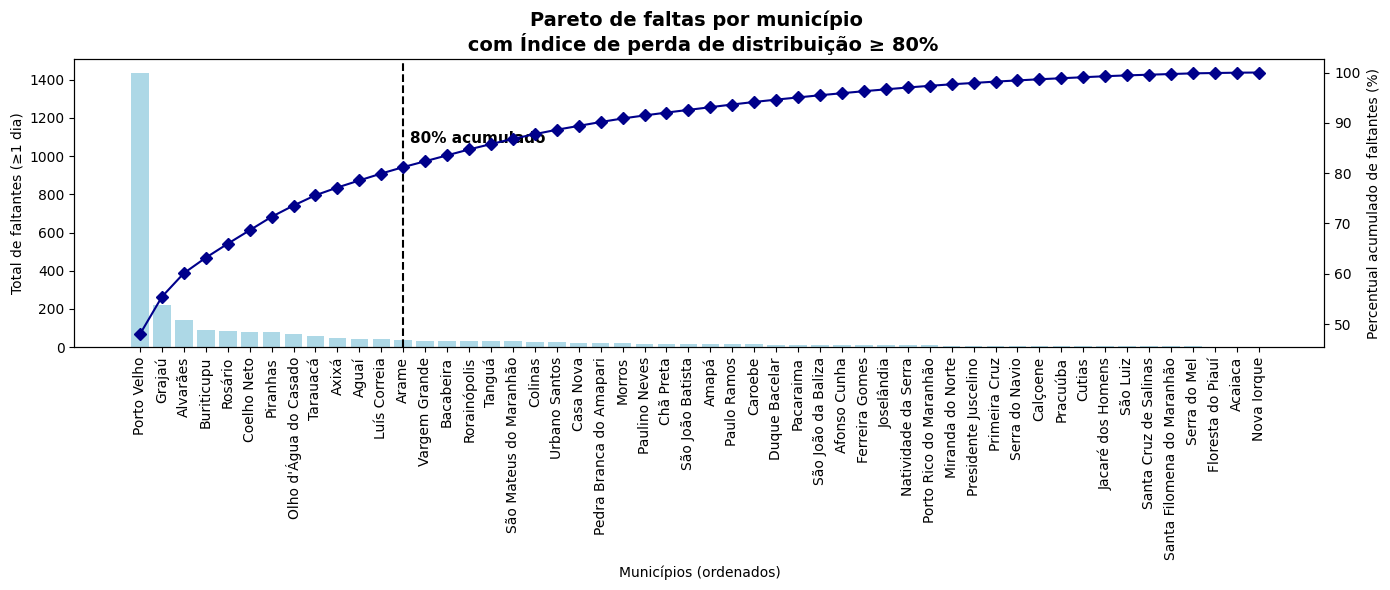

In [ ]:
df_plot = df_q2_merged[
    ["NO_MUNICIPIO_ESC", "NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"]
].copy()
df_plot = df_plot.sort_values("NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT", ascending=False)
df_plot["CUMULATIVE_PERCENT"] = (
    df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"].cumsum()
    / df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"].sum()
) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    df_plot["NO_MUNICIPIO_ESC"],
    df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"],
    color="lightblue",
)
ax.set_ylabel("Total de faltantes (≥1 dia)")
ax.set_xlabel("Municípios (ordenados)")

idx_80 = df_plot["CUMULATIVE_PERCENT"].ge(80).idxmax()
x_80 = df_plot.index.get_loc(idx_80)

ymax = ax.get_ylim()[1]

ax.axvline(x=x_80, linestyle="--", color="black")
ax.text(
    x_80 + 0.3,
    ymax * 0.7,
    r"80% acumulado",
    va="bottom",
    ha="left",
    fontdict={"size": 11, "weight": "bold"},
)

ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot["NO_MUNICIPIO_ESC"], rotation=90)

ax2 = ax.twinx()
ax2.plot(
    df_plot["NO_MUNICIPIO_ESC"],
    df_plot["CUMULATIVE_PERCENT"],
    marker="D",
    linestyle="-",
    color="darkblue",
)
ax2.set_ylabel("Percentual acumulado de faltantes (%)")

plt.title(
    "Pareto de faltas por município \n com Índice de perda de distribuição ≥ 80%",
    fontsize=14,
    fontdict={"weight": "bold"},
)
plt.tight_layout()
plt.show()

In [ ]:
df_q2[df_q2.NO_MUNICIPIO_ESC == "Porto Velho"].shape[0]

2958

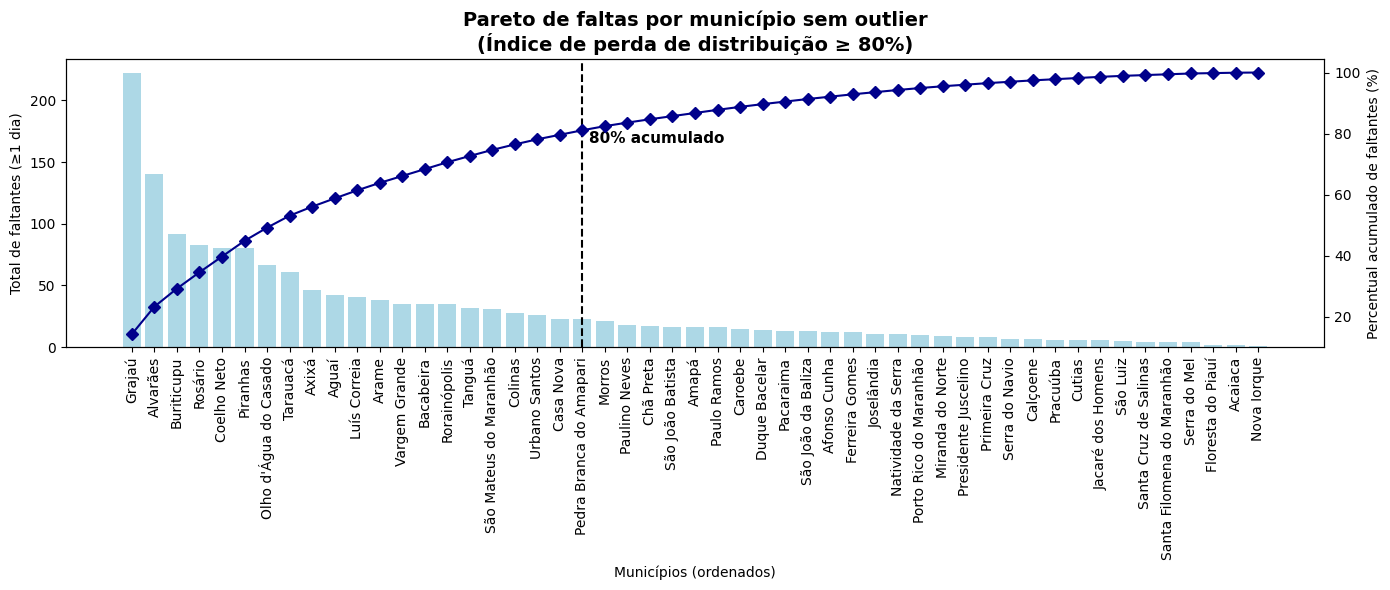

In [ ]:
df_plot = df_q2_merged[df_q2_merged.NO_MUNICIPIO_ESC != "Porto Velho"][
    ["NO_MUNICIPIO_ESC", "NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"]
].copy()
df_plot = df_plot.sort_values("NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT", ascending=False)
df_plot["CUMULATIVE_PERCENT"] = (
    df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"].cumsum()
    / df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"].sum()
) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    df_plot["NO_MUNICIPIO_ESC"],
    df_plot["NAO_COMPARECEU_PELO_MENOS_1_DIA_COUNT"],
    color="lightblue",
)
ax.set_ylabel("Total de faltantes (≥1 dia)")
ax.set_xlabel("Municípios (ordenados)")

idx_80 = df_plot["CUMULATIVE_PERCENT"].ge(80).idxmax()
x_80 = df_plot.index.get_loc(idx_80)

ymax = ax.get_ylim()[1]

ax.axvline(x=x_80, linestyle="--", color="black")
ax.text(
    x_80 + 0.3,
    ymax * 0.7,
    r"80% acumulado",
    va="bottom",
    ha="left",
    fontdict={"size": 11, "weight": "bold"},
)

ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot["NO_MUNICIPIO_ESC"], rotation=90)

ax2 = ax.twinx()
ax2.plot(
    df_plot["NO_MUNICIPIO_ESC"],
    df_plot["CUMULATIVE_PERCENT"],
    marker="D",
    linestyle="-",
    color="darkblue",
)
ax2.set_ylabel("Percentual acumulado de faltantes (%)")

plt.title(
    "Pareto de faltas por município sem outlier\n(Índice de perda de distribuição ≥ 80%)",
    fontsize=14,
    fontdict={"weight": "bold"},
)
plt.tight_layout()
plt.show()

### Análise
Analisando o resultado obtido, a diferença entre os alunos de maior desempenho e menor desempenho é de 60 pontos, condizente com algumas pesquisas feitas pelo grupo como [neste link](https://g1.globo.com/ro/rondonia/noticia/2021/01/18/rondonia-e-o-estado-com-mais-abstencoes-no-enem-feito-em-meio-a-pandemia-645percent-faltaram.ghtml).

### **Conclusão** 🏗️


# **Referências**

[Arquivos auxiliares do SNIS](https://storage.googleapis.com/basedosdados-dev/auxiliary_files/br_mdr_snis/municipio_agua_esgoto/br_mdr_snis_auxiliary_files.zip)

[Micro dados do ENEM](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem)

[Curso de ciência de dados IMT](https://github.com/Rogerio-mack/IMT_CD_2025)


# **Apêndice: Vídeo, GitHub e Datafólio**

Publique (YouTube ou qualquer outro de acesso público) um vídeo explicativo apresentando o seu trabalho em no máximo 4min. Foque na relevância do problema e nos resultados obtidos. Salve em um GitHub público seu projeto (o notebook Python, dados, Datafólio).

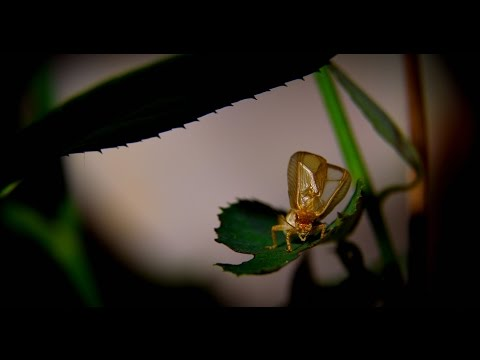

In [ ]:
from IPython.display import YouTubeVideo
YouTubeVideo('ssSCGwy_Qfo') # substitua pelo seu vídeo

In [6]:
#@markdown
#@title **Avaliação**
Completo = 10 #@param {type:"slider", min:0, max:10, step:1}
#@markdown São apresentadas 5-6 perguntas e empregadas estatísticas descritivas, seleções simples e múltiplas, agrupamentos e transformações dos dados.
Relevancia = 9 #@param {type:"slider", min:0, max:10, step:1}
#@markdown O tema é abordado corretamente e as perguntas e análises pertinentes ao problema.
Tecnicas = 10 #@param {type:"slider", min:0, max:10, step:1}
#@markdown As técnicas de gadas estatísticas dos dados, seleções, agrupamentos e transformações são corretamente aplicadas
Apresentacao = 5 #@param {type:"slider", min:0, max:10, step:1}
#@markdown A apresentação dos resultados é clara e objetiva
Conclusao = 3 #@param {type:"slider", min:0, max:10, step:1}
#@markdown As conclusões são justificadas e relevantes
Bonus = 0.5 #@param {type:"slider", min:0, max:1, step:0.5}
#@markdown A critério do professor por inovações na abordagem e no uso de técnicas de Análise de Dados

#@markdown ---
#@markdown ### Apresentação
Datafolio = 0 #@param {type:"slider", min:0, max:10, step:1}
Video = 0 #@param {type:"slider", min:0, max:10, step:1}





In [5]:
#@markdown # **Nota Final**
Nota1 = Completo + Relevancia + Tecnicas + Apresentacao + Conclusao
Nota2 = Datafolio + Apresentacao

nota = (Nota1 + Nota2) / 7 + Bonus

nota = Nota1 / 5 + Bonus

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_tia = []
lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_tia.append(lista[0]); lista_nome.append(lista[1].upper())")

alunos['tia'] = lista_tia
alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 7.9



,tia,nome,nota
0,Enzo Yuji Sakamoto,21.00210-0,7.9
1,João Vitor Choueri Branco,21.01075-7,7.9
2,Pedro Henrique de Sousa Matumoto,21.00784-5,7.9
3,Rafael Rubio Carnes,20.00611-0,7.9
4,Vitor Guirão Soller,21.01444-2,7.9
